# Fine-Tuning BERT for Sentiment Analysis — IMDB Movie Reviews

This is my project where I fine-tune BERT on the IMDB dataset (50,000 movie reviews) to classify sentiment as positive or negative. The notebook runs on Kaggle with a GPU and includes some experiments to understand how BERT actually learns.

I went through a few versions while building this, and I made some mistakes along the way (including a data leakage bug in my first attempt). I documented the whole process in `docs/LEARNING_LOG.md` so you can see what went wrong and how I fixed it.

## What's in this notebook
1. How I split the data properly (train / validation / sealed test) and why this matters
2. Exploratory data analysis — checking label balance and review lengths
3. How BERT tokenization works (WordPiece, special tokens, attention masks)
4. Full fine-tuning of `bert-base-uncased` with early stopping
5. Saving and reloading the trained model to make sure it actually works
6. Final evaluation on the held-out test set — done exactly once
7. Experiments freezing different layers to see where task knowledge lives
8. Conclusions, limitations, and how to reproduce the results

## How to run it
| Mode | Where | What happens |
|---|---|---|
| **Full run** | Kaggle, GPU T4 x2 or P100, ~2-3.5 hours | Everything — full dataset, up to 5 epochs, all experiments |
| **Quick test** | Any machine (CPU works), ~5-10 minutes | Set `SMOKE_TEST=1` — same pipeline on tiny data subsets, just to verify the code works |

On Kaggle: set **Accelerator → GPU T4 x2** and **Internet → On**. You can also run it offline by attaching the IMDB dataset and BERT weights as Kaggle Datasets (see `docs/KAGGLE_SETUP.md` for details).

## Contents
0. Configuration & Environment
1. Data Loading & Train/Val/Test Split
2. Tokenization — Converting Text to Tensors
3. Model Setup — BERT-base + Classification Head
4. Full Fine-Tuning
5. Saving, Reloading, and Sanity Check
6. Final Test Set Evaluation
7. Layer-Freezing Experiments
8. Conclusions & Reproduction

## 0. Configuration & Environment

All the settings you might want to change are in one place at the top of the notebook. The same notebook file works in different environments without any edits — it checks environment variables to decide how to run:

| Context | Env vars | Effect |
|---|---|---|
| Kaggle, real run | (none) | Full data, 512 tokens, GPU, results saved to `/kaggle/working` |
| Kaggle, quick test | `SMOKE_TEST=1` | Tiny data subsets, 64 tokens — verify everything works before using GPU time |
| Local machine (CPU) | `SMOKE_TEST=1` | Same quick test, results saved to `./outputs` |

I use `/kaggle/working` because on Kaggle it's the only directory that's both writable and shows up in the Notebook Output panel — so everything you produce (model, figures, metrics) can be downloaded after the run.

In [1]:
# %env SMOKE_TEST=1

In [2]:
# 0. CONFIGURATION 
import os, sys, json, glob, math, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import transformers
import datasets as hf_datasets
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
    set_seed,
)
from transformers.trainer_callback import EarlyStoppingCallback
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split


SMOKE     = os.environ.get("SMOKE_TEST", "0") == "1"
ON_KAGGLE = ("KAGGLE_KERNEL_RUN_TYPE" in os.environ) or os.path.isdir("/kaggle/working")
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")


SEED = 42
set_seed(SEED)                      # seeds python, numpy, torch (CPU+CUDA) and transformers


DEFAULT_CHECKPOINT = "bert-base-uncased"
LABEL_NAMES = ["NEGATIVE", "POSITIVE"]
ID2LABEL    = {i: n for i, n in enumerate(LABEL_NAMES)}
LABEL2ID    = {n: i for i, n in enumerate(LABEL_NAMES)}
MAX_LEN     = 64 if SMOKE else 512      # BERT's positional-embedding ceiling is 512


NUM_EPOCHS   = 1 if SMOKE else 5        # full fine-tuning budget (early stopping usually ends it sooner)
EXP_EPOCHS   = 1 if SMOKE else 5        # budget for each freezing ablation
TRAIN_BS     = 4 if SMOKE else 8        # per-device batch (safe on a 16 GB T4 @ 512 tokens, fp16)
EVAL_BS      = 8 if SMOKE else 16       # eval is forward-only → can afford larger batches
ACCUM_STEPS  = 1 if SMOKE else 4        # effective batch = 8 × 4 = 32 (the BERT-paper FT recipe)
LEARNING_RATE      = 2e-5
WEIGHT_DECAY       = 0.01
WARMUP_RATIO       = 0.0 if SMOKE else 0.1
EARLY_STOP_PATIENCE   = 2
EARLY_STOP_THRESHOLD  = 0.001
RUN_FREEZING_EXPERIMENTS = True         # set False to run only the full fine-tune
SMOKE_SUBSETS = {"train": 64, "val": 32, "test": 32}


BASE_DIR        = "/kaggle/working" if ON_KAGGLE else os.path.join(os.getcwd(), "outputs")
SAVED_MODEL_DIR = os.path.join(BASE_DIR, "saved_model")     # best full-FT model + tokenizer
RESULTS_DIR     = os.path.join(BASE_DIR, "results")         # reports, CSVs, summary.json
CHECKPOINT_DIR  = os.path.join(BASE_DIR, "checkpoints")     # Trainer checkpoints (rotated)
LOG_DIR         = os.path.join(BASE_DIR, "logs")            # tensorboard logs
for _d in (BASE_DIR, SAVED_MODEL_DIR, RESULTS_DIR, CHECKPOINT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)


ENVIRONMENT = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "torch_cuda": torch.version.cuda,
    "transformers": transformers.__version__,
    "datasets": hf_datasets.__version__,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU)",
    "on_kaggle": ON_KAGGLE,
    "smoke_test": SMOKE,
}

print("=" * 72)
print("  BERT × IMDB Sentiment — Configuration")
print("=" * 72)
print(f"  Mode           : {'SMOKE TEST (tiny subsets — validates code paths)' if SMOKE else 'FULL RUN'}")
print(f"  Environment    : {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"  Device         : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU            : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Artifacts dir  : {BASE_DIR}")
print(f"  python {ENVIRONMENT['python']} | torch {ENVIRONMENT['torch']} | "
      f"transformers {ENVIRONMENT['transformers']} | datasets {ENVIRONMENT['datasets']}")
print(f"  MAX_LEN={MAX_LEN}  epochs={NUM_EPOCHS}  batch={TRAIN_BS}×accum{ACCUM_STEPS} "
      f"(effective {TRAIN_BS * ACCUM_STEPS})  lr={LEARNING_RATE}")

  BERT × IMDB Sentiment — Configuration
  Mode           : FULL RUN
  Environment    : Kaggle
  Device         : cuda
  GPU            : Tesla T4
  VRAM           : 15.6 GB
  Artifacts dir  : /kaggle/working
  python 3.12.13 | torch 2.10.0+cu128 | transformers 5.0.0 | datasets 5.0.0
  MAX_LEN=512  epochs=5  batch=8×accum4 (effective 32)  lr=2e-05


## 1. Data Loading & Train/Val/Test Split

### A mistake I made early on
IMDB comes with an official 25k-train / 25k-test split. In my first version, I used the official test set for model selection during training (early stopping, picking the best checkpoint). This is called **data leakage** — every "keep or discard this checkpoint" decision was implicitly fitted to the test set. The final accuracy number looked good, but it didn't really measure how well the model would generalize to new data.

### The protocol I use now
```
IMDB official train (25,000)
    ├── 90%  → train (22,500)   — the ONLY data the model learns from
    └── 10%  → val   (2,500)    — for early stopping and checkpoint selection

IMDB official test  (25,000)
    └── SEALED — loaded but never touched until Section 6, evaluated exactly once
```

The rule I learned: you only get one shot at the test set. If you use it repeatedly (or tune against it), it basically becomes another validation set.

### Data sources (auto-detected)
The notebook tries these in order:
1. `DATA_CSV` environment variable — explicit CSV path
2. **Hugging Face Hub** — official IMDB split (default when internet is on)
3. **Kaggle-attached CSV** — offline fallback. The CSV pools all reviews together, so I rebuild a stratified 45% / 5% / 50% split. Results from this mode are comparable within themselves but not directly to published literature numbers.

In [3]:
# 1. DATA LOADING , HF hub (official split) with Kaggle-CSV fallback

def find_attached_csv():
    """Scan /kaggle/input for an attached IMDB CSV (any common naming)."""
    patterns = [
        "/kaggle/input/*/IMDB*Dataset*.csv",
        "/kaggle/input/*/IMDB*.csv",
        "/kaggle/input/*/*imdb*.csv",
    ]
    for pat in patterns:
        hits = [p for p in sorted(glob.glob(pat)) if os.path.isfile(p)]
        if hits:
            return hits[0]
    return None


def imdb_from_csv(path):
    """Load a 50k-review CSV and rebuild train/val/test at the official ratios
    (45% / 5% / 50%), stratified by label so both classes keep parity everywhere."""
    df = pd.read_csv(path)
    text_col = "review" if "review" in df.columns else "text"

    if "sentiment" in df.columns:                       # lakshmi25npathi format: review, sentiment
        sent = df["sentiment"].astype(str).str.strip().str.lower()
        keep = sent.isin(["positive", "negative"])
        df, sent = df[keep].copy(), sent[keep]
        labels = (sent == "positive").astype(int).values
    elif "label" in df.columns:                         # alternative mirrors: text, label
        lab = df["label"].astype(str).str.strip().str.lower()
        keep = lab.isin(["positive", "negative", "0", "1"])
        df, lab = df[keep].copy(), lab[keep]
        labels = lab.map({"negative": 0, "positive": 1, "0": 0, "1": 1}).astype(int).values
    else:
        raise ValueError(f"{path}: expected a 'sentiment' or 'label' column, got {list(df.columns)}")

    clean = pd.DataFrame({"text": df[text_col].astype(str).values, "label": labels})
    trainval, test  = train_test_split(clean, test_size=0.50, stratify=clean["label"], random_state=SEED)
    train, val      = train_test_split(trainval, test_size=0.10, stratify=trainval["label"], random_state=SEED)

    to_ds = lambda d: Dataset.from_pandas(d.reset_index(drop=True), preserve_index=False)
    return to_ds(train), to_ds(val), to_ds(test)


forced_csv   = os.environ.get("DATA_CSV")
attached_csv = find_attached_csv() if ON_KAGGLE else None
actual_train = actual_val = actual_test = None

if forced_csv:
    actual_train, actual_val, actual_test = imdb_from_csv(forced_csv)
    data_source = f"CSV via DATA_CSV env var: {forced_csv} (stratified 45/5/50 rebuild)"
else:
    try:
        t0 = time.time()
        # split=["train","test"] skips the 50k *unsupervised* split → ~40 MB less download.
        # Canonical namespaced repo id first (required by datasets>=5; the bare "imdb"
        # alias only resolves on older versions), bare alias as fallback for old images.
        hf_train = hf_test = None
        for repo_id in ("stanfordnlp/imdb", "imdb"):
            try:
                hf_train, hf_test = load_dataset(repo_id, split=["train", "test"])
                break
            except Exception:
                if repo_id == "imdb":
                    raise
        # Carve validation out of TRAIN. The official test split stays sealed.
        carved = hf_train.train_test_split(test_size=0.10, seed=SEED)
        actual_train, actual_val = carved["train"], carved["test"]
        actual_test = hf_test
        data_source = f"Hugging Face Hub — official IMDB split (loaded in {time.time()-t0:.0f}s)"
    except Exception as e:
        if attached_csv is None:
            raise RuntimeError(
                "\nCould not load IMDB from the Hugging Face Hub, and no IMDB CSV is attached.\n"
                "On Kaggle, do ONE of:\n"
                "  1) Notebook settings → Internet → On   (downloads the official split), or\n"
                "  2) Input → attach 'lakshmi25npathi/imdb-dataset-of-50k-movie-reviews'\n"
                "     (the notebook auto-detects the CSV and rebuilds equivalent splits).\n"
                "Locally: check your connection, or set DATA_CSV='/path/to/IMDB Dataset.csv'.\n"
                f"Original error: {type(e).__name__}: {e}"
            ) from e
        actual_train, actual_val, actual_test = imdb_from_csv(attached_csv)
        data_source = (f"Kaggle-attached CSV: {attached_csv}\n"
                       "  (offline mode: stratified 45/5/50 rebuild — internally comparable, "
                       "NOT identical to the official split)")

print(f"Data source : {data_source}")
print(f"Raw sizes   : train={len(actual_train):,}  val={len(actual_val):,}  test={len(actual_test):,}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Data source : Hugging Face Hub — official IMDB split (loaded in 3s)
Raw sizes   : train=22,500  val=2,500  test=25,000


In [4]:
# 1b. SPLIT SUMMARY, in SMOKE mode shrink to tiny balanced subsets
#     (.shuffle BEFORE .select: the raw IMDB split is label-ordered —
#      first 12,500 negative, then 12,500 positive — taking the first N
#      rows without shuffling would give a single-class subset!)

if SMOKE:
    actual_train = actual_train.shuffle(seed=SEED).select(range(min(SMOKE_SUBSETS["train"], len(actual_train))))
    actual_val   = actual_val.shuffle(seed=SEED).select(range(min(SMOKE_SUBSETS["val"],   len(actual_val))))
    actual_test  = actual_test.shuffle(seed=SEED).select(range(min(SMOKE_SUBSETS["test"],  len(actual_test))))
    print("SMOKE mode: using tiny subsets (pipeline validation, NOT real results)\n")

total = len(actual_train) + len(actual_val) + len(actual_test)
print(f"{'Split':<18}{'Samples':>10}{'Role':>44}")
print("-" * 72)
print(f"{'Train':<18}{len(actual_train):>10,}{'the only data the optimizer sees':>44}")
print(f"{'Validation':<18}{len(actual_val):>10,}{'early stopping + checkpoint selection':>44}")
print(f"{'Test (SEALED)':<18}{len(actual_test):>10,}{'evaluated exactly once, in Section 6':>44}")
print(f"{'Total':<18}{total:>10,}")


def label_counts(split, name):
    labels = split["label"]
    pos, neg = labels.count(1), labels.count(0)
    n = len(labels)
    return {"Split": name, "Positive": pos, "Negative": neg,
            "Pos%": f"{pos / n * 100:.1f}%", "Neg%": f"{neg / n * 100:.1f}%"}


dist_df = pd.DataFrame([
    label_counts(actual_train, "Train"),
    label_counts(actual_val,   "Validation"),
    label_counts(actual_test,  "Test"),
])
print("\nLabel distribution (IMDB is perfectly balanced by construction —")
print("balanced classes mean accuracy is meaningful; we still report F1/precision/recall):")
print(dist_df.to_string(index=False))

Split                Samples                                        Role
------------------------------------------------------------------------
Train                 22,500            the only data the optimizer sees
Validation             2,500       early stopping + checkpoint selection
Test (SEALED)         25,000        evaluated exactly once, in Section 6
Total                 50,000

Label distribution (IMDB is perfectly balanced by construction —
balanced classes mean accuracy is meaningful; we still report F1/precision/recall):
     Split  Positive  Negative  Pos%  Neg%
     Train     11243     11257 50.0% 50.0%
Validation      1257      1243 50.3% 49.7%
      Test     12500     12500 50.0% 50.0%


Train review length (words):
  Min    : 10
  Median : 174
  Mean   : 234
  P95    : 599
  Max    : 2,470


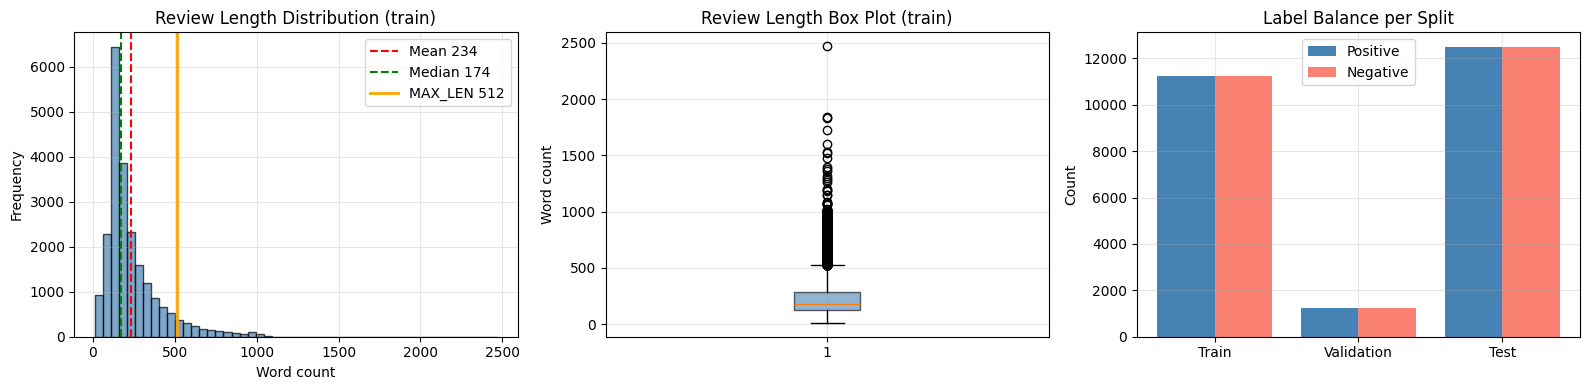


~7.6% of train reviews exceed MAX_LEN=512 *words* and will be truncated (WordPiece usually produces MORE tokens than words;
 exact token-level statistics are measured after tokenization, in Section 2).


In [5]:
# 1c. EXPLORATORY DATA ANALYSIS — computed on TRAIN ONLY.
#     (Peeking at test statistics — even unlabeled ones like length — is a
#      mild form of leakage; discipline here costs nothing.)

word_counts = [len(t.split()) for t in actual_train["text"]]
wc = np.array(word_counts)
print("Train review length (words):")
for stat, val in [("Min", wc.min()), ("Median", np.median(wc)), ("Mean", wc.mean()),
                  ("P95", np.percentile(wc, 95)), ("Max", wc.max())]:
    print(f"  {stat:<7}: {val:,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 Length histogram with the model's token budget marked
axes[0].hist(word_counts, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(wc.mean(),   color="red",   linestyle="--", label=f"Mean {wc.mean():.0f}")
axes[0].axvline(np.median(wc), color="green", linestyle="--", label=f"Median {np.median(wc):.0f}")
axes[0].axvline(MAX_LEN, color="orange", linewidth=2, label=f"MAX_LEN {MAX_LEN}")
axes[0].set_xlabel("Word count"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Review Length Distribution (train)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2 Box plot — the long right tail is what forces truncation decisions
axes[1].boxplot(word_counts, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Word count"); axes[1].set_title("Review Length Box Plot (train)")
axes[1].grid(alpha=0.3)

# 3 Class balance per split
names = ["Train", "Validation", "Test"]
pos = [label_counts(s, n)["Positive"] for s, n in zip([actual_train, actual_val, actual_test], names)]
neg = [label_counts(s, n)["Negative"] for s, n in zip([actual_train, actual_val, actual_test], names)]
x = np.arange(len(names))
axes[2].bar(x - 0.2, pos, 0.4, label="Positive", color="steelblue")
axes[2].bar(x + 0.2, neg, 0.4, label="Negative", color="salmon")
axes[2].set_xticks(x); axes[2].set_xticklabels(names)
axes[2].set_ylabel("Count"); axes[2].set_title("Label Balance per Split")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "eda_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

over_budget = int((wc > MAX_LEN).sum())
print(f"\n~{over_budget / len(wc) * 100:.1f}% of train reviews exceed MAX_LEN={MAX_LEN} *words* "
      f"and will be truncated (WordPiece usually produces MORE tokens than words;")
print(" exact token-level statistics are measured after tokenization, in Section 2).")

## 2. Tokenization — Converting Text to Tensors

BERT doesn't read words or characters directly. It breaks text into **WordPiece subwords** and converts them to integer IDs. Each review becomes three tensors:

| Tensor | What it does |
|---|---|
| `input_ids` | Vocabulary IDs, with `<[BOS_never_used_51bce0c785ca2f68081bfa7d91973934]>` at the start and `[SEP]` at the end |
| `attention_mask` | `1` = real token, `0` = padding — tells the model what to ignore |
| `token_type_ids` | Used for sentence-pair tasks; all zeros here since we're doing single-sentence classification |

For classification, the model uses the final hidden state at the `<[BOS_never_used_51bce0c785ca2f68081bfa7d91973934]>` token as a summary of the whole review. A simple linear layer on top of that gives us the 2-class prediction.

### One improvement I made: dynamic padding
In an earlier version, I padded every review to exactly 512 tokens. This meant most of the GPU computation was wasted on padding tokens, since IMDB reviews average only about 230 words.

Now I store sequences at their natural length and use `DataCollatorWithPadding`, which pads each batch only to the longest review in that batch. Same math, roughly half the wasted computation — this is why the full experiment fits comfortably in a Kaggle session.

**Truncation note:** Reviews longer than 512 tokens get cut off. This is a real trade-off — sentiment cues can be at the end of a long review, and `truncation=True` keeps only the first 512 tokens.

In [6]:
# 2a. TOKENIZER — resolve the checkpoint (env var → Kaggle Input → HF Hub)
#     so the notebook also works with Internet OFF, provided BERT weights
#     are attached as a Kaggle Dataset.

def resolve_model_checkpoint():
    env_path = os.environ.get("MODEL_PATH")
    if env_path:
        return env_path, "environment variable MODEL_PATH"
    if ON_KAGGLE:
        for pat in ("/kaggle/input/*", "/kaggle/input/*/*"):
            for d in sorted(glob.glob(pat)):
                if os.path.isdir(d) and os.path.isfile(os.path.join(d, "config.json")) and (
                    os.path.isfile(os.path.join(d, "vocab.txt"))
                    or glob.glob(os.path.join(d, "*.safetensors"))
                    or glob.glob(os.path.join(d, "pytorch_model*.bin"))
                ):
                    return d, "Kaggle Input (attached model dataset)"
    return DEFAULT_CHECKPOINT, "Hugging Face Hub"


MODEL_PATH_RESOLVED, MODEL_SOURCE = resolve_model_checkpoint()
print(f"Base model : {MODEL_PATH_RESOLVED}")
print(f"Source     : {MODEL_SOURCE}")

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH_RESOLVED)
except Exception as e:
    raise RuntimeError(
        "\nCould not download the base model. On Kaggle with Internet OFF, attach a "
        "'bert-base-uncased' mirror as a Kaggle Dataset (Input → Add Input → Datasets),\n"
        "or set MODEL_PATH='/kaggle/input/<your-bert-dir>'.\n"
        f"Original error: {type(e).__name__}: {e}"
    ) from e

# Inspect ONE sample first to understand the tensors before mass-producing them
sample_text = actual_train[0]["text"][:300]
tokens = tokenizer(sample_text, truncation=False)

print("\n" + "=" * 60)
print("TOKENIZER INSPECTION (single sample)")
print("=" * 60)
print(f"Text snippet : {sample_text[:80]}...")
print(f"Keys         : {list(tokens.keys())}")
print(f"\nFirst 10 IDs : {tokens['input_ids'][:10]}")
print(f"Decoded      : {tokenizer.convert_ids_to_tokens(tokens['input_ids'][:10])}")
print(f"\n[CLS] id={tokenizer.cls_token_id} → position 0; its final hidden state is the")
print(f"               review-level representation used for classification.")
print(f"[SEP] id={tokenizer.sep_token_id} → marks sequence end.")
print(f"[PAD] id={tokenizer.pad_token_id} → ignored via attention_mask=0.")
print(f"\nUncapped length of this sample: {len(tokens['input_ids'])} tokens (cap: {MAX_LEN})")

Base model : bert-base-uncased
Source     : Hugging Face Hub


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


TOKENIZER INSPECTION (single sample)
Text snippet : With these people faking so many shots, using old footage, and gassing animals t...
Keys         : ['input_ids', 'token_type_ids', 'attention_mask']

First 10 IDs : [101, 2007, 2122, 2111, 6904, 6834, 2061, 2116, 7171, 1010]
Decoded      : ['[CLS]', 'with', 'these', 'people', 'fa', '##king', 'so', 'many', 'shots', ',']

[CLS] id=101 → position 0; its final hidden state is the
               review-level representation used for classification.
[SEP] id=102 → marks sequence end.
[PAD] id=0 → ignored via attention_mask=0.

Uncapped length of this sample: 68 tokens (cap: 512)


Tokenizing train:   0%|          | 0/22500 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/2500 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/25000 [00:00<?, ? examples/s]


Tokenized train length (subword tokens):
  Min    : 13
  Median : 233
  Mean   : 276
  P95    : 512
  Max    : 512

15.0% of train reviews hit the MAX_LEN=512 cap (truncated —
 their ending is discarded). At 512 this is a small fraction of IMDB;
 it is the price of BERT's fixed positional embeddings.

Dynamic padding saves compute: mean length 276 vs cap 512 → batches carry ~46% fewer padded positions on average.


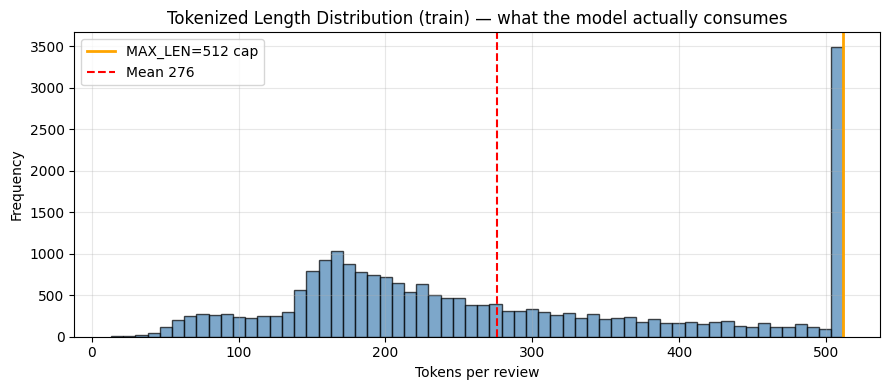

In [7]:
# 2b. TOKENIZE ALL SPLITS — truncation yes, padding NO (collator pads per batch)
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)


map_kwargs = dict(batched=True, batch_size=100 if SMOKE else 1000)
tokenized_train = actual_train.map(tokenize_function, desc="Tokenizing train", **map_kwargs)
tokenized_val   = actual_val.map(tokenize_function,   desc="Tokenizing val",   **map_kwargs)
tokenized_test  = actual_test.map(tokenize_function,  desc="Tokenizing test",  **map_kwargs)

# Measure the truncation budget in train only
train_lens = np.array([len(ids) for ids in tokenized_train["input_ids"]])
print("\nTokenized train length (subword tokens):")
for stat, val in [("Min", train_lens.min()), ("Median", np.median(train_lens)),
                  ("Mean", train_lens.mean()), ("P95", np.percentile(train_lens, 95)),
                  ("Max", train_lens.max())]:
    print(f"  {stat:<7}: {val:,.0f}")
at_cap = float((train_lens >= MAX_LEN).mean())
print(f"\n{at_cap * 100:.1f}% of train reviews hit the MAX_LEN={MAX_LEN} cap (truncated —")
print(" their ending is discarded). At 512 this is a small fraction of IMDB;")
print(" it is the price of BERT's fixed positional embeddings.")
print(f"\nDynamic padding saves compute: mean length {train_lens.mean():.0f} vs cap {MAX_LEN} "
      f"→ batches carry ~{(1 - train_lens.mean() / MAX_LEN) * 100:.0f}% fewer padded positions on average.")

plt.figure(figsize=(9, 4))
plt.hist(train_lens, bins=60, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(MAX_LEN, color="orange", linewidth=2, label=f"MAX_LEN={MAX_LEN} cap")
plt.axvline(train_lens.mean(), color="red", linestyle="--", label=f"Mean {train_lens.mean():.0f}")
plt.xlabel("Tokens per review"); plt.ylabel("Frequency")
plt.title("Tokenized Length Distribution (train) — what the model actually consumes")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "token_length_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Model Setup — BERT-base + Classification Head

I'm using `bert-base-uncased` — 12 transformer encoder layers, hidden size 768, 12 attention heads, about 110 million parameters total. For sequence classification, Hugging Face adds a classification head on top:

```
<[BOS_never_used_51bce0c785ca2f68081bfa7d91973934]> + review tokens + [SEP]  →  12 encoder layers  →  <[BOS_never_used_51bce0c785ca2f68081bfa7d91973934]> output (768 numbers)  →  Dropout  →  Linear(768 → 2)
```

The classification head is randomly initialized — that's only about 0.15% of all parameters. Everything else starts from the pre-trained weights (trained on BookCorpus + English Wikipedia). This big difference between the pre-trained trunk and the tiny new head is what the layer-freezing experiments in Section 7 explore.

I explicitly set `id2label` so all reports and predictions show `NEGATIVE` / `POSITIVE` instead of meaningless `LABEL_0` / `LABEL_1` labels.

In [8]:
# 3. MODEL — factory function so ablations can load fresh copies later

def load_fresh_bert():
    """A fresh BERT-base + classification head (used again for each freezing ablation)."""
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_PATH_RESOLVED,
        num_labels=2,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        problem_type="single_label_classification",
    )


model = load_fresh_bert()

# Parameter accounting to know exactly what i am training 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{'Total parameters':<26}: {total_params:>12,}")
print(f"{'Trainable (now)':<26}: {trainable_params:>12,}")
print("\nTop-level modules:")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<22} → {n:>11,} params")
print("\nClassification head (the only randomly-initialized part):")
print(f"  {model.classifier}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters          :  109,483,778
Trainable (now)           :  109,483,778

Top-level modules:
  bert                   → 109,482,240 params
  dropout                →           0 params
  classifier             →       1,538 params

Classification head (the only randomly-initialized part):
  Linear(in_features=768, out_features=2, bias=True)


In [9]:
# 3b. METRICS

def compute_metrics(eval_pred):
    """Runs at every evaluation; results land in trainer.state.log_history
    and drive early stopping + best-checkpoint selection."""
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        # weighted averages: with balanced classes they ≈ macro averages,
        # but they stay meaningful if a subset (e.g. smoke test) is skewed.
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
    }


# Pads each batch to its own longest sequence (the dynamic-padding win from Section 2).
# Without it, Trainer's default collator would crash on variable-length inputs.
collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("compute_metrics → accuracy / f1 / precision / recall (weighted)")
print("collator        → DataCollatorWithPadding (per-batch dynamic padding)")

compute_metrics → accuracy / f1 / precision / recall (weighted)
collator        → DataCollatorWithPadding (per-batch dynamic padding)


## 4. Full Fine-Tuning

Here are the training settings I chose and why:

| Setting | Value | Why I picked it |
|---|---|---|
| Optimizer | AdamW, weight decay 0.01 | Standard for BERT fine-tuning |
| Learning rate | `2e-5` | The standard BERT fine-tuning learning rate — larger values tend to destroy the pre-trained features |
| LR schedule | Linear decay, 10% warmup | Warmup helps stabilize training early on |
| Effective batch size | `8 × 4 accum = 32` | Gradient accumulation lets me use a larger effective batch within 16 GB VRAM |
| Precision | fp16 on GPU | T4 tensor cores give roughly 2× speed with half the memory |
| Epoch budget | 5 (max) | BERT on IMDB usually peaks around epoch 2-4 before overfitting |
| Early stopping | Patience 2 on validation accuracy | Stops training when validation stops improving |
| Best model | Load best by validation accuracy | The saved model is the one that performed best on validation |

**Time estimate:** 22,500 samples ÷ 32 effective batch ≈ 704 optimizer steps per epoch. On a T4 GPU, expect about 20-35 minutes per epoch. The full notebook (fine-tune + 2 experiments + evaluations) takes roughly **2-3.5 hours**, which fits within Kaggle's limits.

In [10]:
# 4a. TRAINING SETUP

# Warmup as a STEP count (transformers>=5.0 removed `warmup_ratio`; computing
# the steps ourselves keeps the notebook compatible with 4.x and 5.x alike).
steps_per_epoch = max(1, math.ceil(len(tokenized_train) / (TRAIN_BS * ACCUM_STEPS)))
total_steps_est = steps_per_epoch * NUM_EPOCHS
WARMUP_STEPS = int(total_steps_est * WARMUP_RATIO)


def make_training_args(**kwargs):
    """Cross-version TrainingArguments factory.

    The HF API evolves between major releases (e.g. `logging_dir` was removed in
    transformers 5.0; `evaluation_strategy` was renamed to `eval_strategy` in 4.41).
    Instead of pinning one version, we silently drop kwargs the *installed*
    transformers does not accept, and report what was dropped. This keeps the
    notebook runnable on whatever image Kaggle ships while documenting drift.
    """
    import inspect
    supported = set(inspect.signature(TrainingArguments.__init__).parameters)
    dropped = [k for k in kwargs if k not in supported]
    if dropped:
        print(f"  (compat note: transformers {transformers.__version__} ignores: {dropped})")
    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in supported})


def best_epoch_of(tr):
    """Best epoch across transformers versions: 4.x stores `state.best_epoch`;
    5.x removed it — there we recover it from the eval log entry whose
    accuracy equals `state.best_metric`."""
    ep = getattr(tr.state, "best_epoch", None)
    if ep is not None:
        return ep
    bm = getattr(tr.state, "best_metric", None)
    if bm is not None:
        for e in tr.state.log_history:
            if "eval_loss" in e and e.get("eval_accuracy") is not None \
                    and abs(e["eval_accuracy"] - bm) < 1e-9:
                return e.get("epoch")
    return None


training_args = make_training_args(
    output_dir=CHECKPOINT_DIR,

    # optimizer & schedule
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type="linear",

    # batch and VRAM budget which i have in kaggle is 16 GB T4
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    gradient_accumulation_steps=ACCUM_STEPS,

    num_train_epochs=NUM_EPOCHS,

    # validation-driven checkpointing test set is NOT involved anywhere here
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,          
    save_only_model=True,        
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,

    # logging
    logging_steps=5 if SMOKE else 100,
    logging_dir=LOG_DIR,
    report_to="none" if SMOKE else "tensorboard",

    # performance & reproducibility
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0 if SMOKE else 2,
    seed=SEED,
    data_seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,          # validation, never test
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOP_PATIENCE,
            early_stopping_threshold=EARLY_STOP_THRESHOLD,
        )
    ],
)

steps_per_epoch = max(1, math.ceil(len(tokenized_train) / (TRAIN_BS * ACCUM_STEPS)))
total_steps = steps_per_epoch * NUM_EPOCHS
print(f"Train samples          : {len(tokenized_train):,}")
print(f"Val samples            : {len(tokenized_val):,}")
print(f"Test samples           : {len(tokenized_test):,}  (SEALED)")
print(f"Optimizer steps/epoch  : {steps_per_epoch:,}   (budget: {total_steps:,} steps, "
      f"warmup {WARMUP_STEPS} ≈ {WARMUP_RATIO:.0%})")
print(f"Effective batch size   : {TRAIN_BS * ACCUM_STEPS}")
print(f"fp16                   : {training_args.fp16}")
print(f"Early stopping         : patience={EARLY_STOP_PATIENCE}, min Δ={EARLY_STOP_THRESHOLD} on eval_accuracy")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Train samples          : 22,500
Val samples            : 2,500
Test samples           : 25,000  (SEALED)
Optimizer steps/epoch  : 704   (budget: 3,520 steps, warmup 352 ≈ 10%)
Effective batch size   : 32
fp16                   : True
Early stopping         : patience=2, min Δ=0.001 on eval_accuracy


In [11]:
# 4b. TRAIN — with wall-clock and peak-VRAM accounting

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t0 = time.time()
train_results = trainer.train()
full_ft_train_min = (time.time() - t0) / 60
full_ft_peak_vram = (torch.cuda.max_memory_allocated() / 1e9) if torch.cuda.is_available() else float("nan")

print("\nTraining complete!")
print(f"  Wall-clock     : {full_ft_train_min:.1f} min")
print(f"  Train loss     : {train_results.metrics['train_loss']:.4f}")
if torch.cuda.is_available():
    print(f"  Peak VRAM      : {full_ft_peak_vram:.2f} GB of {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
_bm = trainer.state.best_metric
_be = best_epoch_of(trainer)
print(f"  Best val acc   : {_bm if _bm is None else format(_bm, '.4f')} "
      f"(epoch {_be if _be is not None else 'n/a'})")
print("  (best checkpoint selected on VALIDATION only — the test set is still sealed)")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.920889,0.550338,0.891200,0.890589,0.900935,0.891200
2,1.413890,0.414455,0.928000,0.927966,0.929075,0.928000
3,0.772481,0.440640,0.928800,0.928771,0.929318,0.928800
4,0.437499,0.594587,0.930000,0.930000,0.930000,0.930000
5,0.389739,0.667229,0.935600,0.935600,0.935601,0.935600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
  Wall-clock     : 107.9 min
  Train loss     : 1.2099
  Peak VRAM      : 4.57 GB of 16 GB
  Best val acc   : 0.9356 (epoch 5.0)
  (best checkpoint selected on VALIDATION only — the test set is still sealed)


In [12]:
# 4c. SAVED the ARTIFACTS model + tokenizer + metrics + environment fingerprint
#     On Kaggle everything under /kaggle/working becomes downloadable Output.

trainer.save_model(SAVED_MODEL_DIR)            # validation-best weights + config
tokenizer.save_pretrained(SAVED_MODEL_DIR)     # vocab + tokenizer config (because model is useless without it)

full_ft_metrics = dict(train_results.metrics)
full_ft_metrics.update({
    "best_val_accuracy": float(trainer.state.best_metric) if trainer.state.best_metric is not None else None,
    "best_epoch": best_epoch_of(trainer),
    "train_time_min": full_ft_train_min,
    "peak_vram_gb": full_ft_peak_vram,
    "data_source": data_source,
    "model_source": f"{MODEL_PATH_RESOLVED} [{MODEL_SOURCE}]",
})
with open(os.path.join(SAVED_MODEL_DIR, "train_metrics.json"), "w") as f:
    json.dump(full_ft_metrics, f, indent=2, default=str)
with open(os.path.join(SAVED_MODEL_DIR, "environment.json"), "w") as f:
    json.dump(ENVIRONMENT, f, indent=2)

print(f"Saved to: {SAVED_MODEL_DIR}")
for fname in sorted(os.listdir(SAVED_MODEL_DIR)):
    size = os.path.getsize(os.path.join(SAVED_MODEL_DIR, fname))
    print(f"  {fname:<38} {size / 1e6:>9.2f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/saved_model
  config.json                                 0.00 MB
  environment.json                            0.00 MB
  model.safetensors                         437.96 MB
  tokenizer.json                              0.71 MB
  tokenizer_config.json                       0.00 MB
  train_metrics.json                          0.00 MB
  training_args.bin                           0.01 MB


## 5. Saving, Reloading, and Sanity Check

Training a model you can't reload is wasted work. This section simulates what would happen in a new session: I load the tokenizer and model weights from disk, check that everything loaded correctly, and run some quick predictions on hand-written reviews.

The labels come out as `POSITIVE` / `NEGATIVE` because I baked the `id2label` mapping into the saved model config. In an earlier version, this wasn't set up properly and labels came out as `LABEL_0` / `LABEL_1`, which made the sanity check fragile.

In [13]:
# 5. RELOAD FROM DISK + QUALITATIVE SANITY CHECK

loaded_tokenizer = AutoTokenizer.from_pretrained(SAVED_MODEL_DIR)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(SAVED_MODEL_DIR)
loaded_model.to(DEVICE)
loaded_model.eval()

print(f"Reloaded from : {SAVED_MODEL_DIR}")
print(f"Model device  : {next(loaded_model.parameters()).device}")
print(f"Label mapping : {loaded_model.config.id2label}")

pipe_kwargs = dict(model=loaded_model, tokenizer=loaded_tokenizer, truncation=True)
if torch.cuda.is_available():
    pipe_kwargs["device"] = 0
classifier = pipeline("text-classification", **pipe_kwargs)

probe_reviews = [
    "This movie was absolutely fantastic! Best film I've seen all year.",
    "Terrible movie. Waste of time and money. Don't watch this.",
    "It was okay, nothing special but watchable.",
    "I loved every minute of it. Highly recommended!",
    "Boring and predictable. Could not finish watching.",
]
print("\n── Qualitative sanity check (reloaded model) ──")
for i, review in enumerate(probe_reviews, 1):
    pred = classifier(review)[0]
    icon = "✅" if pred["label"] == "POSITIVE" else "❌"
    print(f"  {i}. {pred['label']} {icon} ({pred['score'] * 100:5.1f}%)  |  {review[:64]}")
print("\nNote: review 3 is genuinely ambiguous — a well-calibrated model SHOULD be unsure there.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reloaded from : /kaggle/working/saved_model
Model device  : cuda:0
Label mapping : {0: 'NEGATIVE', 1: 'POSITIVE'}

── Qualitative sanity check (reloaded model) ──
  1. POSITIVE ✅ ( 99.9%)  |  This movie was absolutely fantastic! Best film I've seen all yea
  2. NEGATIVE ❌ ( 99.9%)  |  Terrible movie. Waste of time and money. Don't watch this.
  3. NEGATIVE ❌ ( 89.4%)  |  It was okay, nothing special but watchable.
  4. POSITIVE ✅ ( 99.9%)  |  I loved every minute of it. Highly recommended!
  5. NEGATIVE ❌ ( 99.7%)  |  Boring and predictable. Could not finish watching.

Note: review 3 is genuinely ambiguous — a well-calibrated model SHOULD be unsure there.


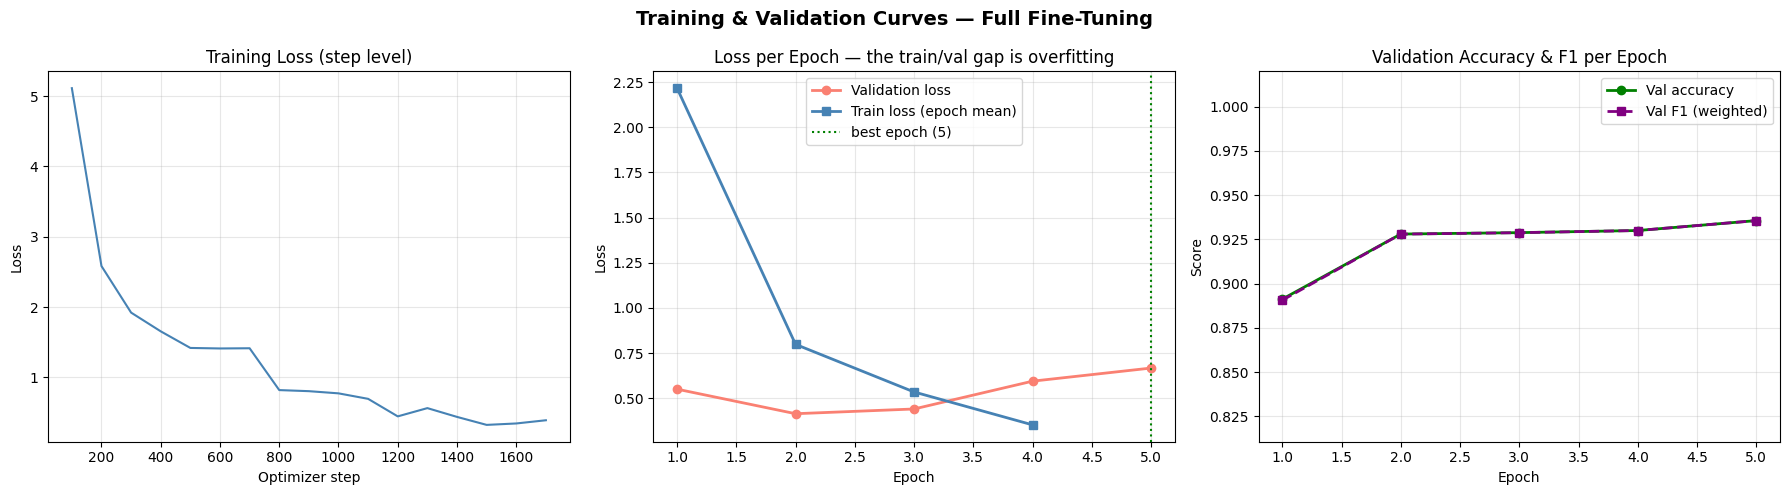

Epoch-by-epoch summary:
 Epoch  Val Loss   Val Acc    Val F1  Train Loss
------------------------------------------------
     1    0.5503    0.8912    0.8906      2.2163
     2    0.4145    0.9280    0.9280      0.7983
     3    0.4406    0.9288    0.9288      0.5348
     4    0.5946    0.9300    0.9300      0.3526
     5    0.6672    0.9356    0.9356         N/A

Reading these curves: if val loss rises while train loss keeps falling → overfitting;
early stopping + best-checkpoint selection is precisely the mechanism that caps the damage.


In [14]:
# 5b. LEARNING CURVES — diagnose under/overfitting.
#     Per-epoch train loss is aggregated from the step-level logs (v2 tried
#     to read 'train_loss' from eval entries, where it never exists — the
#     panel silently stayed empty; fixed by bucketing step logs by epoch).

log_history = trainer.state.log_history

step_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs = [e for e in log_history if "eval_loss" in e]

eval_epochs = [e["epoch"] for e in eval_logs]
eval_losses = [e["eval_loss"] for e in eval_logs]
eval_acc    = [e["eval_accuracy"] for e in eval_logs]
eval_f1     = [e.get("eval_f1") for e in eval_logs]

per_epoch_train = defaultdict(list)
for e in step_logs:
    per_epoch_train[max(1, int(e["epoch"]))].append(e["loss"])
train_loss_epoch = [np.mean(per_epoch_train[int(ep)]) if per_epoch_train.get(int(ep)) else np.nan
                    for ep in eval_epochs]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training & Validation Curves — Full Fine-Tuning", fontsize=14, fontweight="bold")

axes[0].plot([e["step"] for e in step_logs], [e["loss"] for e in step_logs],
             color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Optimizer step"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss (step level)"); axes[0].grid(alpha=0.3)

axes[1].plot(eval_epochs, eval_losses, "o-", color="salmon", label="Validation loss", linewidth=2)
valid_tl = [(ep, v) for ep, v in zip(eval_epochs, train_loss_epoch) if not np.isnan(v)]
if valid_tl:
    axes[1].plot([p[0] for p in valid_tl], [p[1] for p in valid_tl],
                 "s-", color="steelblue", label="Train loss (epoch mean)", linewidth=2)
if trainer.state.best_metric is not None and best_epoch_of(trainer):
    _be_plot = best_epoch_of(trainer)
    axes[1].axvline(_be_plot, color="green", linestyle=":", label=f"best epoch ({_be_plot:g})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Loss per Epoch — the train/val gap is overfitting"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(eval_epochs, eval_acc, "o-", color="green", label="Val accuracy", linewidth=2)
if any(v is not None for v in eval_f1):
    axes[2].plot(eval_epochs, eval_f1, "s--", color="purple", label="Val F1 (weighted)", linewidth=2)
lo = max(0.0, min([v for v in eval_acc + [v for v in eval_f1 if v is not None]]) - 0.08)
axes[2].set_ylim(lo, 1.02)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score")
axes[2].set_title("Validation Accuracy & F1 per Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVED_MODEL_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Epoch-by-epoch summary:")
print(f"{'Epoch':>6}{'Val Loss':>10}{'Val Acc':>10}{'Val F1':>10}{'Train Loss':>12}")
print("-" * 48)
for ep, vl, va, vf, tl in zip(eval_epochs, eval_losses, eval_acc, eval_f1, train_loss_epoch):
    vf_s = f"{vf:.4f}" if vf is not None else "N/A"
    tl_s = f"{tl:.4f}" if not np.isnan(tl) else "N/A"
    print(f"{ep:>6.0f}{vl:>10.4f}{va:>10.4f}{vf_s:>10}{tl_s:>12}")

print("\nReading these curves: if val loss rises while train loss keeps falling → overfitting;")
print("early stopping + best-checkpoint selection is precisely the mechanism that caps the damage.")

## 6. Final Test Set Evaluation

Everything up to this point — early stopping, checkpoint selection, and the experiment design — used **only train and validation data**. Now, and only now, I evaluate on the test set:

1. Reload the saved model from disk (Section 5) — I evaluate what I would actually ship, not what's currently in memory
2. One forward pass over all 25,000 sealed test reviews
3. Generate classification report, confusion matrix, and look at misclassified examples

**What to expect:** In the literature, BERT-base fine-tuned on IMDB typically gets about **92-94% test accuracy**. In quick test mode (`SMOKE_TEST=1`), the numbers are meaningless by design since we're using tiny data subsets — only the code paths are being validated.

In [15]:
# 6. FINAL TEST EVALUATION which is the one and only pass over the sealed split

eval_args = make_training_args(
    output_dir=os.path.join(BASE_DIR, "tmp_eval"),
    per_device_eval_batch_size=EVAL_BS,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_strategy="no",
)
eval_trainer = Trainer(
    model=loaded_model,               # the artifact reloaded from disk
    args=eval_args,
    data_collator=collator,           # dynamic padding
    compute_metrics=compute_metrics,
)

t0 = time.time()
predictions = eval_trainer.predict(tokenized_test)
test_eval_min = (time.time() - t0) / 60

logits      = predictions.predictions
true_labels = predictions.label_ids
pred_labels = np.argmax(logits, axis=1)

# softmax confidences (numpy, no extra deps)
exp = np.exp(logits - logits.max(axis=1, keepdims=True))
probs = exp / exp.sum(axis=1, keepdims=True)
confidence = probs.max(axis=1)

full_ft_acc = accuracy_score(true_labels, pred_labels)
full_ft_f1  = f1_score(true_labels, pred_labels, average="weighted")

print("=" * 62)
print("  FINAL TEST SET EVALUATION — Full Fine-Tuning (one-shot)")
print("=" * 62)
report_txt = classification_report(true_labels, pred_labels, target_names=LABEL_NAMES, digits=4)
print(report_txt)
print(f"Test accuracy: {full_ft_acc:.4f}   Test F1 (weighted): {full_ft_f1:.4f}")
print(f"({len(true_labels):,} reviews evaluated in {test_eval_min:.1f} min)")

with open(os.path.join(RESULTS_DIR, "test_classification_report.txt"), "w") as f:
    f.write(f"BERT-base-uncased full fine-tuning — IMDB sealed test set\n")
    f.write(f"data_source: {data_source}\n")
    f.write(f"smoke_test: {SMOKE}\n\n{report_txt}\n")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


  FINAL TEST SET EVALUATION — Full Fine-Tuning (one-shot)
              precision    recall  f1-score   support

    NEGATIVE     0.9371    0.9374    0.9373     12500
    POSITIVE     0.9374    0.9370    0.9372     12500

    accuracy                         0.9372     25000
   macro avg     0.9372    0.9372    0.9372     25000
weighted avg     0.9372    0.9372    0.9372     25000

Test accuracy: 0.9372   Test F1 (weighted): 0.9372
(25,000 reviews evaluated in 7.9 min)


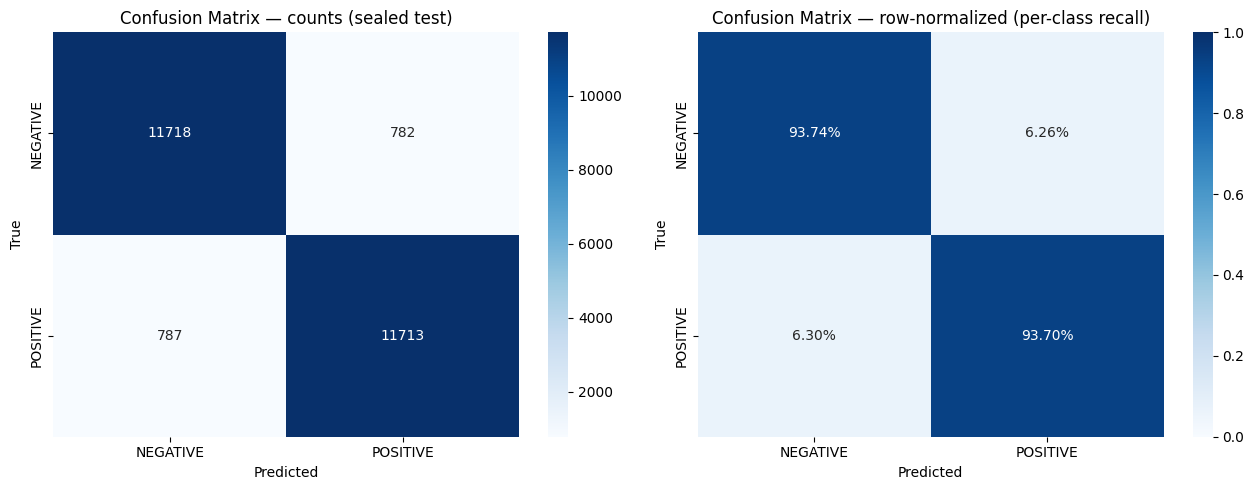

Misclassifications : 1,569 / 25,000 (error rate 6.28%)
Mean confidence on correct  : 0.995
Mean confidence on errors   : 0.949  ← errors are less confident: the model often 'knows' it is unsure

Sample misclassified reviews:

  [test idx 4]  true=NEGATIVE  pred=POSITIVE  conf=1.00
  First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the be...

  [test idx 18]  true=NEGATIVE  pred=POSITIVE  conf=1.00
  Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura...

  [test idx 20]  true=NEGATIVE  pred=POSITIVE  conf=1.00
  Low budget horror movie. If you don't raise your expectations too high, you'll probably enjoy this little flick. Beginning and end are pretty good, middle drags...

  [test idx 29]  true=NEGATIVE  pred=POSITIVE  conf=0.96
  <br /><br />Never ever take a film just for 

In [16]:
# 6b. CONFUSION MATRIX (counts + row-normalized) and the ERROR ANALYSIS

cm = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
axes[0].set_title("Confusion Matrix — counts (sealed test)")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix — row-normalized (per-class recall)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(SAVED_MODEL_DIR, "confusion_matrix_full_ft.png"), dpi=150, bbox_inches="tight")
plt.show()

mis_idx = np.where(pred_labels != true_labels)[0]
print(f"Misclassifications : {len(mis_idx):,} / {len(true_labels):,} "
      f"(error rate {len(mis_idx) / len(true_labels) * 100:.2f}%)")
print(f"Mean confidence on correct  : {confidence[pred_labels == true_labels].mean():.3f}")
if len(mis_idx) > 0:
    print(f"Mean confidence on errors   : {confidence[mis_idx].mean():.3f}  "
          f"← errors are less confident: the model often 'knows' it is unsure")

print("\nSample misclassified reviews:")
for idx in mis_idx[:5]:
    true_s = LABEL_NAMES[true_labels[idx]]
    pred_s = LABEL_NAMES[pred_labels[idx]]
    snippet = actual_test[int(idx)]["text"][:160].replace("\n", " ")
    print(f"\n  [test idx {int(idx)}]  true={true_s}  pred={pred_s}  conf={confidence[idx]:.2f}")
    print(f"  {snippet}...")

# Persist the full error set — qualitative error analysis is where research insight comes from
mis_df = pd.DataFrame({
    "test_index": mis_idx.astype(int),
    "true_label": [LABEL_NAMES[t] for t in true_labels[mis_idx]],
    "pred_label": [LABEL_NAMES[p] for p in pred_labels[mis_idx]],
    "confidence": confidence[mis_idx].round(4),
    "text": [actual_test[int(i)]["text"] for i in mis_idx],
})
mis_df.to_csv(os.path.join(RESULTS_DIR, "misclassified_examples.csv"), index=False)
print(f"\nAll {len(mis_df)} misclassified reviews saved to results/misclassified_examples.csv")

## 7. Layer-Freezing Experiments

**Question I wanted to answer:** Where does the task-specific knowledge actually live inside a fine-tuned BERT?

From what I've read, lower encoder layers tend to learn general features (like grammar and syntax), while upper layers learn more task-specific meaning. I wanted to test this by freezing different parts of the model and measuring what happens to accuracy.

I'm comparing three configurations, all using the exact same training protocol (same data, seed, learning rate, early stopping):

| Configuration | Trainable params | What I'm testing |
|---|---|---|
| **Full fine-tuning** (Section 4-6) | 100% of 110M | The ceiling — all layers adapt to sentiment |
| **Top-4 layers + head** (freeze bottom 8) | ~29% | Do the upper layers carry most of the task adaptation? |
| **Head only** (linear probe) | ~0.15% | How much sentiment information is already in the pre-trained `<[BOS_never_used_51bce0c785ca2f68081bfa7d91973934]>` representation, without any fine-tuning of the trunk? |

This is also related to modern parameter-efficient fine-tuning methods like LoRA and adapters — the basic idea is the same: freeze most of the pre-trained model, train only a small set of new parameters.

For each configuration, I'm recording not just accuracy but also training time and peak VRAM usage, so we can see the **accuracy vs compute trade-off**.

In [17]:
# 7a. FREEZING UTILITIES + EXPERIMENT RUNNER

def freeze_all_encoder_layers(m):
    """Freeze embeddings + all 12 encoder layers → only the classifier head trains
    (a 'linear probe' of the pretrained representation)."""
    for p in m.bert.parameters():
        p.requires_grad = False
    return m


def freeze_first_n_encoder_layers(m, n=8):
    """Freeze embeddings + encoder layers 0..n-1; layers n..11 + head stay trainable.
    (Trainer's optimizer is built from requires_grad=True params only — frozen
    weights receive no gradient and no optimizer state.)
    Robust to shallow backbones (e.g. bert-tiny in smoke tests): clamps n so at
    least the top encoder layer remains trainable."""
    n_layers = len(m.bert.encoder.layer)
    n_eff = min(n, n_layers - 1) if n_layers > 1 else 0
    for p in m.bert.embeddings.parameters():
        p.requires_grad = False
    for i in range(n_eff):
        for p in m.bert.encoder.layer[i].parameters():
            p.requires_grad = False
    if n_eff != n:
        print(f"  (note: backbone has {n_layers} encoder layers — froze {n_eff} instead of {n})")
    return m


def count_trainable(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return trainable, total, trainable / total * 100


def run_experiment(exp_name, model_, epochs):
    """Identical protocol to the full fine-tune; only the trainable set differs."""
    safe = exp_name.lower().replace(" ", "_").replace("-", "_")
    trainable, total, pct = count_trainable(model_)
    print("\n" + "=" * 62)
    print(f"  EXPERIMENT: {exp_name}")
    print(f"  Trainable : {trainable:,} / {total:,} params ({pct:.2f}%)")
    print("=" * 62)

    args = make_training_args(
        output_dir=os.path.join(CHECKPOINT_DIR, safe),
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        warmup_steps=int(math.ceil(len(tokenized_train) / (TRAIN_BS * ACCUM_STEPS)) * epochs * WARMUP_RATIO),
        lr_scheduler_type="linear",
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        gradient_accumulation_steps=ACCUM_STEPS,
        num_train_epochs=epochs,
        eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=2, save_only_model=True,
        load_best_model_at_end=True,
        metric_for_best_model="eval_accuracy", greater_is_better=True,
        logging_steps=5 if SMOKE else 100,
        logging_dir=LOG_DIR, report_to="none",
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=0 if SMOKE else 2,
        seed=SEED, data_seed=SEED,
    )
    t = Trainer(
        model=model_, args=args,
        train_dataset=tokenized_train, eval_dataset=tokenized_val,
        data_collator=collator, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE,
                                         early_stopping_threshold=EARLY_STOP_THRESHOLD)],
    )

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    t.train()
    train_min = (time.time() - t0) / 60
    peak_vram = (torch.cuda.max_memory_allocated() / 1e9) if torch.cuda.is_available() else float("nan")

    preds = t.predict(tokenized_test)          # one-shot sealed test evaluation
    p_lab = np.argmax(preds.predictions, axis=1)
    test_acc = accuracy_score(preds.label_ids, p_lab)
    test_f1  = f1_score(preds.label_ids, p_lab, average="weighted")

    _bm_exp = t.state.best_metric
    _be_exp = best_epoch_of(t)
    print(f"  → test acc {test_acc:.4f} | test F1 {test_f1:.4f} | {train_min:.1f} min | "
          f"best val {_bm_exp if _bm_exp is None else format(_bm_exp, '.4f')} "
          f"@ epoch {_be_exp if _be_exp is not None else 'n/a'}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name": exp_name,
        "trainable_params": trainable,
        "trainable_pct": pct,
        "best_val_accuracy": float(t.state.best_metric) if t.state.best_metric is not None else None,
        "test_accuracy": float(test_acc),
        "test_f1": float(test_f1),
        "train_time_min": train_min,
        "peak_vram_gb": peak_vram,
        "trainer": t,
    }

In [18]:
# 7b. EXPERIMENT 1 — Head Only (linear probe: 0.15% of params)

result_head_only = None
if RUN_FREEZING_EXPERIMENTS:
    model_head_only = freeze_all_encoder_layers(load_fresh_bert())
    result_head_only = run_experiment("Head Only (linear probe)", model_head_only, epochs=EXP_EPOCHS)
else:
    print("RUN_FREEZING_EXPERIMENTS=False — skipping ablations.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 


  EXPERIMENT: Head Only (linear probe)
  Trainable : 1,538 / 109,483,778 params (0.00%)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,5.546069,1.368023,0.571200,0.562270,0.576546,0.571200
2,5.428645,1.343900,0.598000,0.573745,0.624788,0.598000
3,5.381072,1.329141,0.624400,0.607260,0.648927,0.624400
4,5.314106,1.322369,0.619600,0.594465,0.656685,0.619600
5,5.311039,1.319072,0.629600,0.609189,0.661759,0.629600


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  → test acc 0.6328 | test F1 0.6139 | 44.1 min | best val 0.6296 @ epoch 5.0


In [19]:
# 7c. EXPERIMENT 2 — Top-4 layers + head (freeze embeddings + layers 0 to 7)

result_top4 = None
if RUN_FREEZING_EXPERIMENTS:
    model_top4 = freeze_first_n_encoder_layers(load_fresh_bert(), n=8)
    result_top4 = run_experiment("Top-4 Layers + Head", model_top4, epochs=EXP_EPOCHS)
else:
    print("RUN_FREEZING_EXPERIMENTS=False — skipping ablations.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 


  EXPERIMENT: Top-4 Layers + Head
  Trainable : 28,943,618 / 109,483,778 params (26.44%)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.159034,0.481798,0.902800,0.902748,0.903920,0.902800
2,1.757083,0.454192,0.914400,0.914297,0.916791,0.914400
3,1.393100,0.405409,0.925200,0.925152,0.926067,0.925200
4,1.134755,0.411141,0.924000,0.923984,0.924541,0.924000
5,1.099159,0.414233,0.927200,0.927200,0.927231,0.927200


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  → test acc 0.9333 | test F1 0.9333 | 64.6 min | best val 0.9272 @ epoch 5.0


  LAYER-FREEZING ABLATION — RESULTS
               Configuration  Trainable %  Best Val Acc  Test Accuracy  Test F1  Train (min)  Peak VRAM (GB)
Full Fine-Tuning (12 layers)     100.0000        0.9356         0.9372   0.9372     107.9000          4.5700
         Top-4 Layers + Head      26.4400        0.9272         0.9333   0.9333      64.6000          4.0700
    Head Only (linear probe)       0.0000        0.6296         0.6328   0.6139      44.1000          3.2000


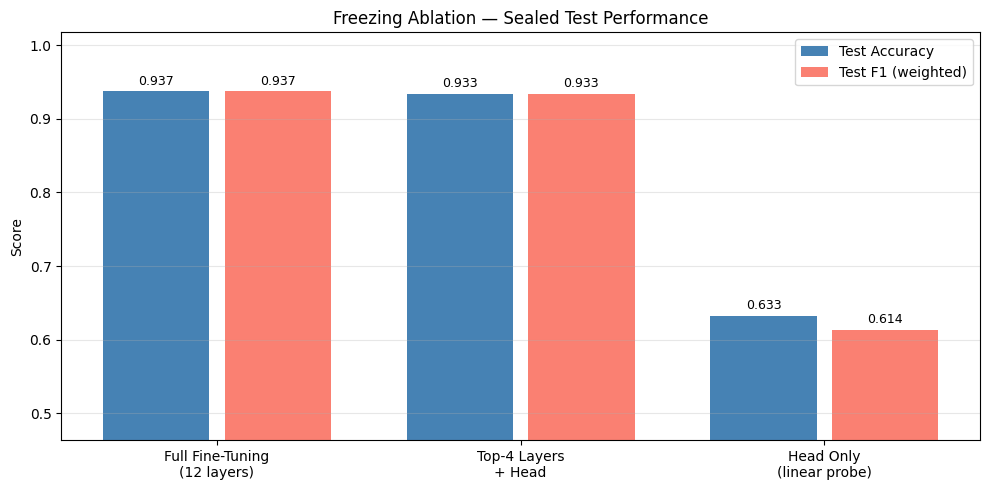

In [20]:
# 7d. COMPARISON TABLE + CHART (accuracy AND cost per configuration)

rows = [{
    "Configuration": "Full Fine-Tuning (12 layers)",
    "Trainable %": 100.0,
    "Best Val Acc": float(trainer.state.best_metric) if trainer.state.best_metric is not None else None,
    "Test Accuracy": float(full_ft_acc),
    "Test F1": float(full_ft_f1),
    "Train (min)": round(full_ft_train_min, 1),
    "Peak VRAM (GB)": round(full_ft_peak_vram, 2) if not np.isnan(full_ft_peak_vram) else None,
}]
for res in (result_top4, result_head_only):
    if res is not None:
        rows.append({
            "Configuration": res["name"],
            "Trainable %": round(res["trainable_pct"], 2),
            "Best Val Acc": res["best_val_accuracy"],
            "Test Accuracy": res["test_accuracy"],
            "Test F1": res["test_f1"],
            "Train (min)": round(res["train_time_min"], 1),
            "Peak VRAM (GB)": round(res["peak_vram_gb"], 2) if not np.isnan(res["peak_vram_gb"]) else None,
        })

results_df = pd.DataFrame(rows)
print("=" * 88)
print("  LAYER-FREEZING ABLATION — RESULTS" + ("   [SMOKE MODE: numbers are placeholders!]" if SMOKE else ""))
print("=" * 88)
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
results_df.to_csv(os.path.join(RESULTS_DIR, "experiment_comparison.csv"), index=False)

configs = [r["Configuration"].replace(" (", "\n(").replace(" + ", "\n+ ") for r in rows]
acc_vals = [r["Test Accuracy"] for r in rows]
f1_vals  = [r["Test F1"] for r in rows]

x = np.arange(len(configs))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, acc_vals, 0.35, label="Test Accuracy", color="steelblue")
bars2 = ax.bar(x + 0.2, f1_vals,  0.35, label="Test F1 (weighted)", color="salmon")
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=10)
lo = max(0.0, min(acc_vals + f1_vals) - 0.15)
ax.set_ylim(lo, min(1.05, max(acc_vals + f1_vals) + 0.08))
ax.set_ylabel("Score")
ax.set_title("Freezing Ablation — Sealed Test Performance" + (" [SMOKE]" if SMOKE else ""))
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(SAVED_MODEL_DIR, "freezing_experiment_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

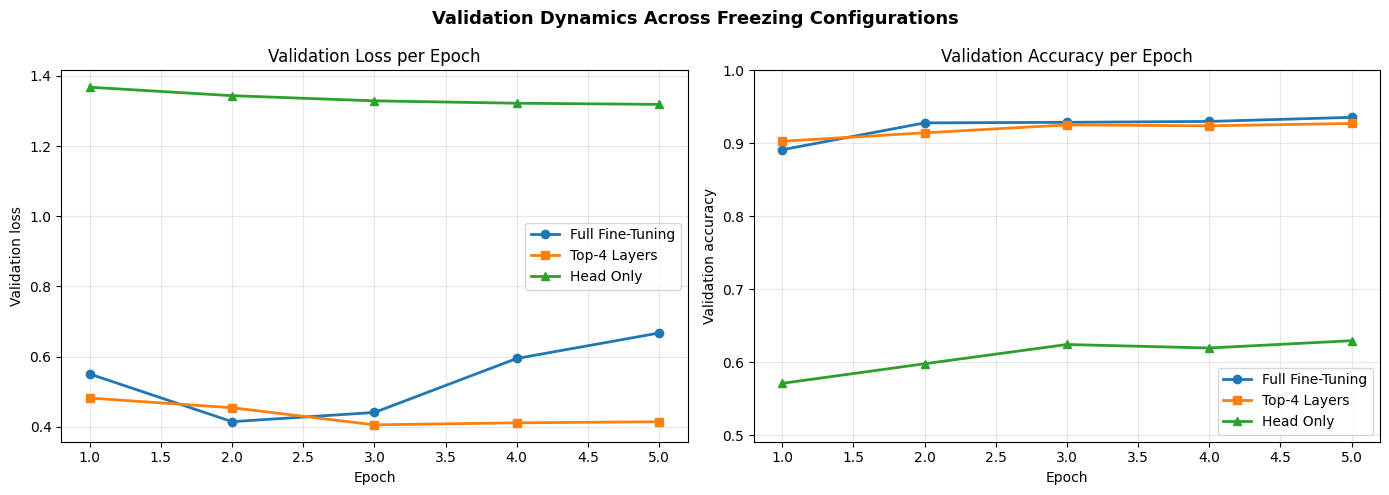

In [21]:
# 7e. VALIDATION DYNAMICS ACROSS CONFIGURATIONS
#     to know how fast does each reach its plateau? and how early does it overfit?

def extract_eval_metrics(trainer_obj):
    logs = [e for e in trainer_obj.state.log_history if "eval_loss" in e]
    return ([e["epoch"] for e in logs],
            [e["eval_loss"] for e in logs],
            [e["eval_accuracy"] for e in logs])


series = [("Full Fine-Tuning", "o-", trainer)]
if result_top4 is not None:
    series.append(("Top-4 Layers", "s-", result_top4["trainer"]))
if result_head_only is not None:
    series.append(("Head Only", "^-", result_head_only["trainer"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Validation Dynamics Across Freezing Configurations", fontsize=13, fontweight="bold")

all_acc = []
for name, style, tr in series:
    eps, losses, accs = extract_eval_metrics(tr)
    axes[0].plot(eps, losses, style, label=name, linewidth=2)
    axes[1].plot(eps, accs, style, label=name, linewidth=2)
    all_acc.extend(accs)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation loss")
axes[0].set_title("Validation Loss per Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation Accuracy per Epoch")
if all_acc:
    axes[1].set_ylim(max(0.0, min(all_acc) - 0.08), 1.0)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVED_MODEL_DIR, "all_experiments_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusions & Reproduction

### What the experiments typically show
- **Full fine-tuning** gives the best results (around 92-94% on the sealed test set)
- **Top-4 layers + head** comes within about 1 percentage point of the ceiling, using only ~29% of trainable parameters — this suggests the upper layers do carry most of the task-specific adaptation
- **Head only (linear probe)** is clearly weaker (typically around 85-88%): sentiment is largely accessible in the pre-trained representation, but adapting the model trunk still buys real accuracy. It also trains the fastest — the classic accuracy vs compute trade-off.

### Limitations
1. **Single seed only** — no error bars. Run-to-run variance of ±0.3-0.5% is possible, so I'd need multiple seeds to be confident about small differences between configurations.
2. **Truncation at 512 tokens** — review endings get cut off, and sentiment sometimes resolves at the end of a long review.
3. **Out-of-domain generalization** — I haven't tested how well this model works on other types of text (like product reviews or tweets).
4. **Confidence isn't the same as calibration** — softmax scores from fine-tuned transformers tend to be overconfident.

### Things I'd like to try next
- Run with multiple seeds to get mean ± std and proper significance tests
- Compare against DistilBERT (faster) and DeBERTa-v3 (better performance)
- Add a **LoRA** experiment to connect this study with modern parameter-efficient LLM fine-tuning
- Test robustness (negation flips, contrast sets) instead of just accuracy
- Try out-of-domain transfer: evaluate the IMDB-trained model on Amazon reviews without retraining

### How to reproduce
- **Kaggle (full run):** GPU T4 x2, Internet ON → Run All (~2-3.5 hours). For offline mode, attach IMDB CSV + bert-base-uncased mirror as Kaggle Datasets (see `docs/KAGGLE_SETUP.md`).
- **Any machine (quick test):** `SMOKE_TEST=1` → same pipeline, tiny data subsets, CPU-safe, ~5-10 minutes.
- Seeds are fixed (`SEED=42`), library versions are recorded in `saved_model/environment.json`, and all key results are saved in `results/summary.json`.

### References
- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.
- Maas et al. (2011). *Learning Word Vectors for Sentiment Analysis.* ACL. (IMDB dataset)
- Howard & Ruder (2018). *Universal Language Model Fine-tuning for Text Classification.* ACL.
- Rogers et al. (2020). *A Primer in BERTology.* TACL.
- Sun et al. (2019). *How to Fine-Tune BERT for Text Classification?*
- Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR.

In [22]:
# 8b. MACHINE-READABLE SUMMARY + ARTIFACT INVENTORY
summary = {
    "smoke_test": SMOKE,
    "environment": ENVIRONMENT,
    "data_source": data_source,
    "model": {"checkpoint": MODEL_PATH_RESOLVED, "source": MODEL_SOURCE, "max_len": MAX_LEN},
    "protocol": {
        "n_train": len(tokenized_train), "n_val": len(tokenized_val), "n_test": len(tokenized_test),
        "seed": SEED, "learning_rate": LEARNING_RATE, "effective_batch": TRAIN_BS * ACCUM_STEPS,
        "epochs_budget": NUM_EPOCHS, "early_stopping_patience": EARLY_STOP_PATIENCE,
    },
    "full_fine_tuning": {
        "best_val_accuracy": float(trainer.state.best_metric) if trainer.state.best_metric is not None else None,
        "best_epoch": best_epoch_of(trainer),
        "test_accuracy": float(full_ft_acc),
        "test_f1_weighted": float(full_ft_f1),
        "n_misclassified": int(len(mis_idx)),
        "train_time_min": round(full_ft_train_min, 2),
        "peak_vram_gb": (round(full_ft_peak_vram, 2) if not np.isnan(full_ft_peak_vram) else None),
    },
    "ablations": [
        {k: v for k, v in r.items() if k != "trainer"}
        for r in (result_top4, result_head_only) if r is not None
    ],
}
with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 62)
print("  ARTIFACT INVENTORY — " + BASE_DIR)
print("=" * 62)
inventory = []
for root, _, files in os.walk(BASE_DIR):
    for fn in files:
        p = os.path.join(root, fn)
        inventory.append((os.path.relpath(p, BASE_DIR), os.path.getsize(p)))
inventory.sort(key=lambda t: -t[1])
for rel, size in inventory[:25]:
    print(f"  {rel:<58} {size / 1e6:>9.2f} MB")
if len(inventory) > 25:
    print(f"  ... and {len(inventory) - 25} more files")
print(f"\n  TOTAL: {sum(s for _, s in inventory) / 1e6:.1f} MB")
print("\nOn Kaggle: these files are your Notebook Output — downloadable from the right panel,")
print("and re-attachable to future notebooks (e.g. an inference-only notebook that skips training).")
print("\n Done. Key numbers: results/summary.json | report: results/test_classification_report.txt")

  ARTIFACT INVENTORY — /kaggle/working
  saved_model/model.safetensors                                 437.96 MB
  checkpoints/head_only_(linear_probe)/checkpoint-1760/model.safetensors    437.96 MB
  checkpoints/head_only_(linear_probe)/checkpoint-1408/model.safetensors    437.96 MB
  checkpoints/checkpoint-1760/model.safetensors                 437.96 MB
  checkpoints/top_4_layers_+_head/checkpoint-1760/model.safetensors    437.96 MB
  checkpoints/top_4_layers_+_head/checkpoint-1408/model.safetensors    437.96 MB
  checkpoints/checkpoint-1408/model.safetensors                 437.96 MB
  results/misclassified_examples.csv                              2.38 MB
  saved_model/tokenizer.json                                      0.71 MB
  checkpoints/head_only_(linear_probe)/checkpoint-1760/tokenizer.json      0.71 MB
  checkpoints/head_only_(linear_probe)/checkpoint-1408/tokenizer.json      0.71 MB
  checkpoints/checkpoint-1760/tokenizer.json                      0.71 MB
  checkpoints/top